# Collect detuning data for modeling with KIND

In [1]:
# --! include root folder into PYTHONPATH

import os
import sys

cur_dir = os.getcwd()
root_dir = os.path.abspath(os.path.join(cur_dir, '..', '..'))
sys.path.append(root_dir)

data_dir = '../../data/kalman'

# --! import Python libraries and KIND framework files

import torch
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import util_data
import example_kalman

## Load detuning data

In [2]:
# --! read data from files

data_path = f'{data_dir}/detuning_24-03-2025_15-54_2'
data_frame = pd.read_csv(data_path, skiprows=23, dtype=np.float32, sep='\t', decimal=',')
detuning = torch.from_numpy(data_frame.to_numpy())

print(f'inf > read time series shape is: {detuning.shape}')

inf > read time series shape is: torch.Size([19999, 2])


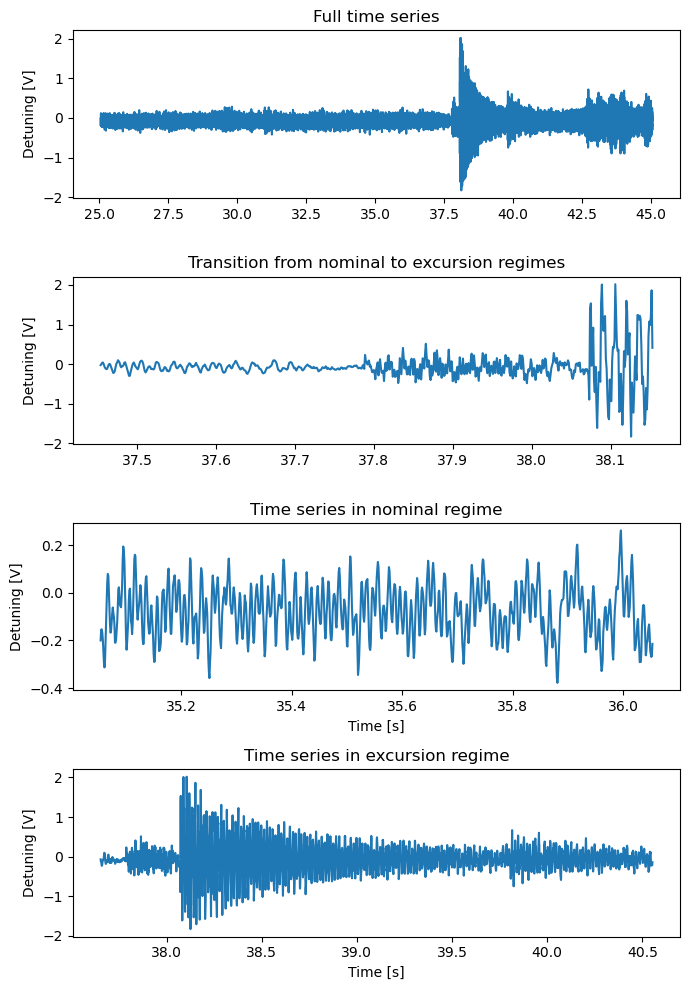

In [3]:
# --! display detuning in time domain

plt.figure(figsize=(7,10))
plt.subplot(4,1,1)
plt.title('Full time series')
plt.plot(detuning[:, 0], detuning[:, 1])
plt.ylabel('Detuning [V]')

plt.subplot(4,1,2)
plt.title('Transition from nominal to excursion regimes')
plt.plot(detuning[12_400:13_100, 0], detuning[12_400:13_100, 1])
plt.ylabel('Detuning [V]')

plt.subplot(4,1,3)
plt.title('Time series in nominal regime')
plt.plot(detuning[10_000:11_000, 0], detuning[10_000:11_000, 1])
plt.ylabel('Detuning [V]')
plt.xlabel('Time [s]')
plt.ylabel('Detuning [V]')

plt.subplot(4,1,4)
plt.title('Time series in excursion regime')
plt.plot(detuning[12_600:15_500, 0], detuning[12_600:15_500, 1])
plt.ylabel('Detuning [V]')
plt.xlabel('Time [s]')

plt.tight_layout()
plt.show()

In [4]:
# --! baseline contains all data of interest
data_baseline = torch.unsqueeze(detuning[9_000:14_000, [1]], 0)
print(f'baseline shape: {data_baseline.shape}')

# --! evaluation contains transition from nominal to excursion regime
data_eval = torch.unsqueeze(detuning[12_500:13_500, [1]], 0)
print(f'evaluation shape: {data_eval.shape}')

baseline shape: torch.Size([1, 5000, 1])
evaluation shape: torch.Size([1, 1000, 1])


## Separate data into regimes

We separate nominal and excursion regimes using heuristic decomposition: no kick, with kick. In such case, the nominal regime represents approximately stationary cavity behavior, excursion regime corresponds to externally perturbed behavior. This engineering approximation should of course be expanded into a more scientifically based solution.

In [5]:
def extract_windows(timeseries, back_nsample, fore_nsample):

    windows = []

    timeseries_nsample = timeseries.shape[0]
    for i in range(timeseries_nsample):
        window_start = i - back_nsample
        window_end = i + fore_nsample
        if window_start >= 0 and window_end <= timeseries_nsample:
            window = timeseries[window_start:window_end, :]
            windows.append(window)

    return torch.stack(windows)

# --! training contains nominal and excursion regions not included in evaluation
data_train_nom = detuning[9_500:12_500, [1]]
data_train_exc = detuning[12_500:15_500, [1]]

back_nsample = 96
fore_nsample = 48

data_train_nom = extract_windows(data_train_nom, back_nsample, fore_nsample)
data_train_exc = extract_windows(data_train_exc, back_nsample, fore_nsample)

print(f'nominal data shape: {data_train_nom.shape}')
print(f'excursion data shape: {data_train_exc.shape}')

nominal data shape: torch.Size([2857, 144, 1])
excursion data shape: torch.Size([2857, 144, 1])


## Save model data

In [6]:
# --! save all data

datasaved = True

if datasaved:
    util_data.write_datafile(f'{data_dir}/baseline', data_baseline)
    util_data.write_datafile(f'{data_dir}/eval', data_eval)
    util_data.write_datafile(f'{data_dir}/nom', data_train_nom)
    util_data.write_datafile(f'{data_dir}/exc', data_train_exc)